Background: Doctors all around the world need our help to predict whether a patient has hypothyroid disease. We have already overspent our budget to collect such complete data on about 30 attributes for 2800 patients--a good starting number, but a larger sample would certainly be preferred. Moving forward, however, we simply cannot afford to spend so much money on data collection. Therefore, we also need to determine which attributes are the most meaningful to the predictive models, and cut out the rest that don't contribute much.

The boss wants to see a **balanced** model that can predict with a **high sensitivity** and **high specificity** while using a ***low amount of features***. Collecting complete data such as this is very rare, very time-consuming, and often very expensive. By minimizing the number of features, it will optimize future data collection by deciding what needs to be collected, and what doesn't.

# Loading the data

Let's read the data into a Pandas dataframe and look at the first 20 records.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
%matplotlib inline

train_url = "https://raw.githubusercontent.com/MedlyticsUniversal/Data/main/Week1/allhypo.train.csv"
test_url = "https://raw.githubusercontent.com/MedlyticsUniversal/Data/main/Week1/allhypo.test.csv"

'''
names = [
    'Age','Sex','On Thyroxine','Query on Thyroxine','On Antithyroid Medication',
    'Sick','Pregnant','Thyroid Surgery','I131 Treatment','Query Hypothyroid',
    'Query Hyperthyroid','Lithium','Goiter','Tumor','Hypopituitary','Psych',
    'TSH Measured','TSH','T3 Measured','T3','TT4 Measured','TT4',
    'T4U Measured','T4U','FTI Measured','FTI','TBG Measured','TBG',
    'Referral Source','Class'
]
'''

train_data = pd.read_csv(train_url, header=0, na_values="?")
test_data = pd.read_csv(test_url, header=0)

train_data.columns = train_data.columns.str.strip().str.lower()
test_data.columns = test_data.columns.str.strip().str.lower()

# identify columns by what time of data they hold
numeric_columns = ["age", "tsh", "t3", "tt4", "t4u", "fti"]

# categorical columns are everything else (minus 'class')
categorical_columns = list(set(train_data.columns)-set(numeric_columns)-set(['class']))

In [ ]:
def format_class_labels(df):
    df = df.copy()

    df["class"] = (
        df["class"]
        .astype(str)
        .str.replace(r"\.\|\d+", "", regex=True)
        .str.strip()
        .str.lower()
    )

    df["class"] = df["class"].replace({
        "negative": 0,
        "compensated hypothyroid": 1,
        "primary hypothyroid": 1,
        "secondary hypothyroid": 1
    })

    df = df.dropna(subset=["class"])
    df["class"] = df["class"].astype(int)

    return df

train_data = format_class_labels(train_data)
train_data.head()

/tmp/ipykernel_1214/1745060249.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["class"] = df["class"].replace({


,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,i131 treatment,query hypothyroid,...,tt4 measured,tt4,t4u measured,t4u,fti measured,fti,tbg measured,tbg,referral source,class
0,41.0,F,f,f,f,f,f,f,f,f,...,t,125.0,t,1.14,t,109.0,f,NaN,SVHC,0
1,23.0,F,f,f,f,f,f,f,f,f,...,t,102.0,f,NaN,f,NaN,f,NaN,other,0
2,46.0,M,f,f,f,f,f,f,f,f,...,t,109.0,t,0.91,t,120.0,f,NaN,other,0
3,70.0,F,t,f,f,f,f,f,f,f,...,t,175.0,f,NaN,f,NaN,f,NaN,other,0
4,70.0,F,f,f,f,f,f,f,f,f,...,t,61.0,t,0.87,t,70.0,f,NaN,SVI,0


In [ ]:
train_data = train_data.drop("referral source", axis=1)
test_data = test_data.drop("referral source", axis=1)

In [ ]:
train_data.describe()

,age,tsh,t3,tt4,t4u,fti,tbg,class
count,2799.00000,2516.000000,2215.000000,2616.000000,2503.000000,2505.000000,0.0,2800.000000
mean,51.84423,4.672150,2.024966,109.072401,0.997912,110.787984,NaN,0.078571
std,20.46116,21.449453,0.824600,35.392443,0.194390,32.883986,NaN,0.269117
min,1.00000,0.005000,0.050000,2.000000,0.310000,2.000000,NaN,0.000000
25%,36.00000,0.440000,1.600000,88.000000,0.880000,93.000000,NaN,0.000000
50%,54.00000,1.400000,2.000000,104.000000,0.980000,107.000000,NaN,0.000000
75%,67.00000,2.600000,2.400000,125.000000,1.080000,124.000000,NaN,0.000000
max,455.00000,478.000000,10.600000,430.000000,2.120000,395.000000,NaN,1.000000


### Split training and testing data

In [ ]:

mapping = {**dict.fromkeys(["F","f"],0),**dict.fromkeys(["M","t"],1),"negative":0,**dict.fromkeys(["compensated hypothyroid","primary hypothyroid","secondary hypothyroid"], 1)}

train_data.replace(mapping, inplace=True)
test_data.replace(mapping, inplace=True)
train_data = train_data.drop_duplicates()






X_cols = ['age','sex','on thyroxine','query on thyroxine','on antithyroid medication',
    'sick','pregnant','thyroid surgery','i131 treatment','query hypothyroid',
    'query hyperthyroid','lithium','goiter','tumor','hypopituitary','psych',
    'tsh measured','tsh','t3 measured','t3','tt4 measured','tt4',
    't4u measured','t4u','fti measured','fti','tbg measured','tbg']

y_col = 'class'

test_size = 0.2
X_train, X_test, y_train, y_test = train_test_split(train_data[X_cols], train_data[y_col], test_size=test_size, random_state=0)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=test_size, random_state=0)



/tmp/ipykernel_1214/1440091079.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_data.replace(mapping, inplace=True)
/tmp/ipykernel_1214/1440091079.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_data.replace(mapping, inplace=True)


In [ ]:
train_data.head()

,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,i131 treatment,query hypothyroid,...,t3,tt4 measured,tt4,t4u measured,t4u,fti measured,fti,tbg measured,tbg,class
0,41.0,0.0,0,0,0,0,0,0,0,0,...,2.5,1,125.0,1,1.14,1,109.0,0,NaN,0
1,23.0,0.0,0,0,0,0,0,0,0,0,...,2.0,1,102.0,0,NaN,0,NaN,0,NaN,0
2,46.0,1.0,0,0,0,0,0,0,0,0,...,NaN,1,109.0,1,0.91,1,120.0,0,NaN,0
3,70.0,0.0,1,0,0,0,0,0,0,0,...,1.9,1,175.0,0,NaN,0,NaN,0,NaN,0
4,70.0,0.0,0,0,0,0,0,0,0,0,...,1.2,1,61.0,1,0.87,1,70.0,0,NaN,0


### Model evaluation

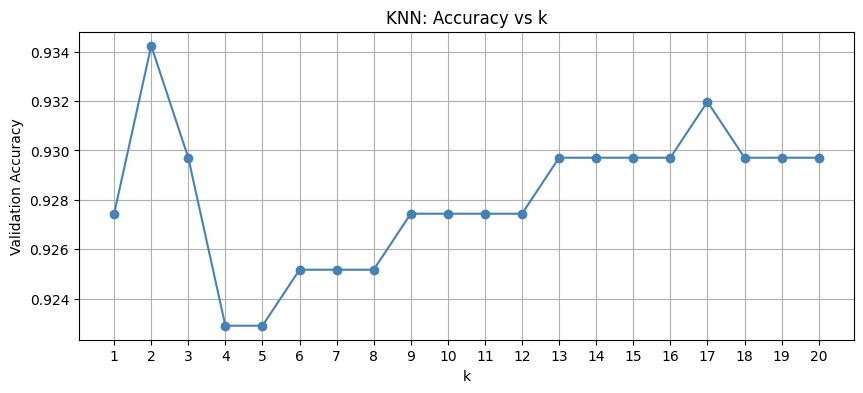

Best k: 2  |  Validation Accuracy: 0.9342


In [ ]:
### K-NN Model evaluation
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns

X_train_knn = X_train.drop(columns=['tbg'], errors='ignore').copy()
X_val_knn   = X_val.drop(columns=['tbg'], errors='ignore').copy()
X_test_knn  = X_test.drop(columns=['tbg'], errors='ignore').copy()

imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
imputer.fit(X_train_knn)                                      # fit on train only

X_train_knn = imputer.transform(X_train_knn)
X_val_knn   = imputer.transform(X_val_knn)
X_test_knn  = imputer.transform(X_test_knn)

# ── 3. Scale ──────────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_knn = scaler.fit_transform(X_train_knn)
X_val_knn   = scaler.transform(X_val_knn)
X_test_knn  = scaler.transform(X_test_knn)

# ── 4. Find best k ────────────────────────────────────────────────────────────
k_range = range(1, 21)
accuracies = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_knn, y_train)
    accuracies.append(accuracy_score(y_val, knn.predict(X_val_knn)))

plt.figure(figsize=(10, 4))
plt.plot(k_range, accuracies, marker='o', color='steelblue')
plt.xlabel('k'); plt.ylabel('Validation Accuracy')
plt.title('KNN: Accuracy vs k')
plt.xticks(k_range); plt.grid(True); plt.show()

best_k = list(k_range)[accuracies.index(max(accuracies))]
print(f"Best k: {best_k}  |  Validation Accuracy: {max(accuracies):.4f}")


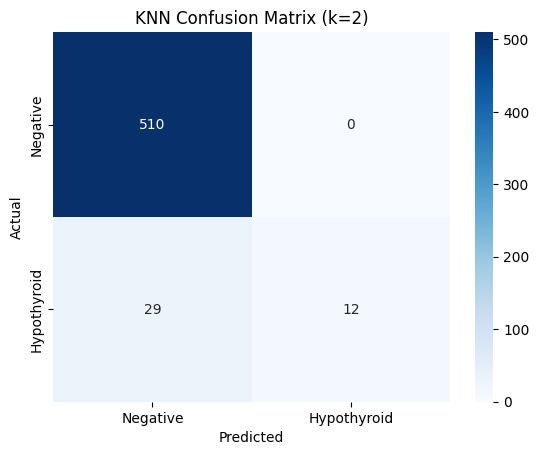

Sensitivity: 0.2927
Specificity: 1.0000
Test Accuracy:    0.9474
Train Accuracy:    0.9546
AUROC:       0.7632
              precision    recall  f1-score   support

    Negative       0.95      1.00      0.97       510
 Hypothyroid       1.00      0.29      0.45        41

    accuracy                           0.95       551
   macro avg       0.97      0.65      0.71       551
weighted avg       0.95      0.95      0.93       551



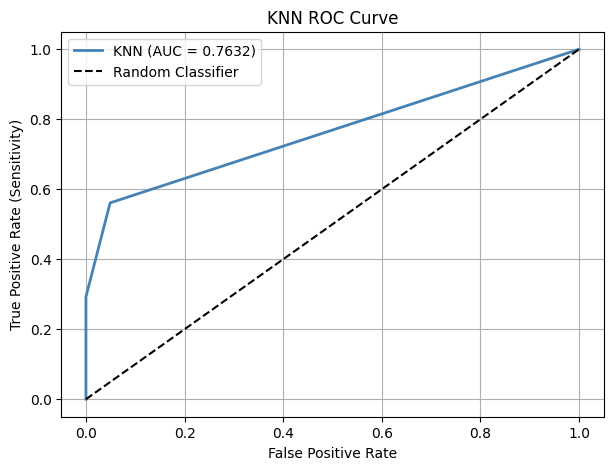

In [ ]:
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_knn, y_train)

y_pred      = knn_final.predict(X_test_knn)
y_pred_prob = knn_final.predict_proba(X_test_knn)
y_pred_train = knn_final.predict(X_train_knn)


cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Hypothyroid'],
            yticklabels=['Negative', 'Hypothyroid'])
plt.title(f'KNN Confusion Matrix (k={best_k})')
plt.ylabel('Actual'); plt.xlabel('Predicted'); plt.show()


tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Test Accuracy:    {accuracy_score(y_test, y_pred):.4f}")
print(f"Train Accuracy:    {accuracy_score(y_train,y_pred_train):.4f}")
print(f"AUROC:       {roc_auc_score(y_test, y_pred_prob[:,1]):.4f}")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Hypothyroid']))

fpr, tpr, _ = roc_curve(y_test, y_pred_prob[:, 1])
auc_score   = roc_auc_score(y_test, y_pred_prob[:, 1])
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'KNN (AUC = {auc_score:.4f})')
plt.plot([0,1], [0,1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('KNN ROC Curve'); plt.legend(); plt.grid(True); plt.show()

To start, let's establish the baseline performance. This is important because it provides a starting point of comparison for later evaluation methods, like accuracy.

A good baseline model to use is the Zero Rule algorithm. In classification problems, it simply predicts the class value with the greatest number of instances every time.

Get your baseline performance by calculating the accuracy of your Zero Rule algorithm.

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

# Feature names after dropping 'tbg'
feature_names_for_knn = [col for col in X_cols if col != 'tbg']

# Apply SelectKBest to get feature scores
# We use f_classif for classification tasks
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_train_knn, y_train)

# Create a DataFrame for feature scores
feature_scores = pd.DataFrame({
    'Feature': feature_names_for_knn,
    'Score': selector.scores_
}).sort_values(by='Score', ascending=False)

display(feature_scores.head(15))

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [14 26] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


,Feature,Score
17,tsh,373.590703
25,fti,140.310489
21,tt4,114.989715
19,t3,55.285085
2,on thyroxine,18.067219
16,tsh measured,14.890919
9,query hypothyroid,3.955341
1,sex,2.969805
20,tt4 measured,2.687060
6,pregnant,2.547355


So maybe accuracy isn't the best performance measure for this dataset. As you've seen already, even when the models predict "negative" for all the records, we could already achieve a ~92% accuracy. However, that also implies we incorrectly predicted 100% of the positive cases, which in the context of this problem, is fatal.

Thankfully, it isn't the only way to evaluate your model. Let's take a look at a confusion matrix.

![alt text](https://i.imgur.com/uipmEwt.png)

Create a confusion matrix using the logistic regression function you built earlier.

In [ ]:
from sklearn.metrics import confusion_matrix
### Your code here


Yet another appropriate metric is the Area Under the Receiver Operator Curve. Specifically, the diagnostic performance of a test, or the accuracy of a test to discriminate diseased cases from normal cases is evaluated using Receiver Operating Characteristic (ROC) curve analysis.

When you consider the results of a particular test in two populations, one population with a disease, the other population without the disease, you will rarely observe a perfect separation between the two groups. Hence, the overlapping areas in the diagram below (FN, FP).

In a Receiver Operating Characteristic (ROC) curve the true positive rate (Sensitivity) is plotted in function of the false positive rate (100-Specificity) for different cut-off points. Each point on the ROC curve represents a sensitivity/specificity pair corresponding to a particular decision threshold. A test with perfect discrimination (no overlap in the two distributions) has a ROC curve that passes through the upper left corner (100% sensitivity, 100% specificity). Therefore the closer the ROC curve is to the upper left corner, the higher the overall accuracy of the test.

![alt text](https://www.medcalc.org/manual/_help/images/roc_intro1.png)





Now, to graph the AUROC curve, we will need to predict probabilities of choosing a specific class value rather than the class value itself. Make a new logistic regression model that does so.

In [ ]:
from sklearn.linear_model import LogisticRegression

### Your code here

Now calculate the area under the receiver operator curve with your predictions.

In [ ]:
from sklearn import metrics

### Your code here

Now graph the ROC curve using matplotlib, fully labeled.

In [ ]:
import matplotlib.pyplot as plt
### Your code here

In conclusion, it looks like this model performed pretty bad. It's probably best to try out different columns or perhaps use a different model before we submit our model for scoring.

# Submitting your Model

Once you believe to have found the best classifier, run your classifier on the test data and make a pickle file containing of your predictions contained a pandas dataframe.

This pandas dataframe will contain three columns for your binary classifier (or 5 columns for the multiclass classifier): the first column should be your model's "best guess" for each patient (either 0 or 1, negative or positive) and the last two columns should be the probability the patient would be classified as either a 0 or 1.

(see below for reference)

In [ ]:
#pickling example
import pickle
predictions=po.DataFrame({"guesses":[0,1,0,1],"prob_neg":[.75,.15,.63,.20],"prob_pos":[.25,.85,.27,.80]})
prediction_pickle_path = 'prediction_pickle.pkl'

from google.colab import files
# Create an variable to pickle and open it in write mode
prediction_pickle = open(prediction_pickle_path, 'wb')
pickle.dump(predictions, prediction_pickle)
files.download(prediction_pickle_path)
prediction_pickle.close()

In [ ]:
prediction_unpickle = open(prediction_pickle_path, 'rb')

# load the unpickle object into a variable
predictions = pickle.load(prediction_unpickle)

print(predictions)

# Scoring your Model


**Area Under ROC Curve**: A receiver operating characteristic (ROC) curve plots the true positive rate (y) against the false positive rate (x) at many decision threshold settings (output < threshold = 0, output > threshold = 1). The area under this curve represents the probability that a classifier will rank a randomly chosen positive instance higher than a randomly chosen negative one.

**Confusion Matrix**: You will receive a certain number of points for each correct classification and a certain point penalty for each incorrect classification. The points are weighted, and are designed to equate to 0 in a Zero Rule baseline model. This point scheme is designed to punish you heavily for predicting false positives (FP) and false negatives (FN)--FN cases especially. In doing so, we hope you see the importance of clinical considerations and treat your models from a more human perspective, rather than detached from it.

**Real World Cost**: Similar to the confusion matrix, we want you to keep in mind the other aspects of healthcare analytics--in this case, economic feasibility. In essence, we want you to minimize the amount of time and money spent on data collection by reducing the number of features collected. Each record certainly required a lot of time and money from several individuals and businesses to reliably create, and we hope you gain a better understanding of conducting a useful cost-benefit analysis with this scoring method. The full details of the weighted features can be found in the GitHub.

# Moving to the Next Level

For those that finish early, remember how I converted the class values into simply "negative" and "positive"? Now try tackling the multiclass classifier (predicting the different types of positive hypothyroid cases instead of simply negative or positive)!

The same rules apply!